# Tracking a moving reference: a preview and a mass parameter in `scaly.ocp`

A cart on a line must follow a position reference that steps by 1 m and then oscillates, with a
bounded force. The OCP names two parameters, the cart's mass and the reference, and one generated
PIQP solver takes their values at every solve, with nothing rebuilt when they change. Declared
`varying`, the reference takes one value per grid point, so the controller sees the next two
seconds of it: a preview. Without that it sees only the reference now, held over the horizon. The
notebook runs both in closed loop, then gives the preview controller the wrong mass, and checks
one solve against NumPy.

| Scaly feature | Where |
| --- | --- |
| a step Function `@sc.function(2, 1, (), output="xnext")` taking `mass` | the model: `mass` becomes a parameter of the OCP |
| `sc.ocp.Quadratic(Q, R, x_ref="r")`, `sc.ocp.TerminalEquality(x_ref="r")` | the MPC: the reference declared by name |
| `problem.params`, the inputs of `sc.ocp.solver(problem, ...)` | the MPC: the parameters in order, and their sizes |
| `sc.ocp.DiscreteOCP(..., varying=("r",))` | the MPC and the closed loops: `N + 1` reference values per solve |
| `sc.ocp.Direct(sc.opt.PIQP(sparse=True))`, `sc.ocp.shift`, a closed loop passing `mass` and `r` | the closed loops: a reference that moves with the step |
| `xs, us, point, info = solve(x0, mass, r, warm)` | what the preview sees, and the NumPy check |
| `si.zoh` | the plant, and the NumPy check |
| a law `@sc.function` of the solver and the shift, `write_module` | the generated C |

This notebook needs the vendored PIQP.

In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly import ocp
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "ocp" / "reference_tracking"

## A cart with its mass as a parameter

A force $u$ held over an interval $\Delta t$ moves a cart of mass $m$, position $p$ and velocity $v$
exactly by

$$
p_{k+1} = p_k + \Delta t\, v_k + \frac{\Delta t^2}{2m} u_k, \qquad v_{k+1} = v_k + \frac{\Delta t}{m} u_k,
\qquad\text{or}\qquad x_{k+1} = A x_k + \tfrac{1}{m} B u_k .
$$

The step Function takes the mass as a third input, a scalar (`()`). An OCP makes every input of
its Functions after the state and the control a parameter, by name, so `mass` becomes one.

The step is written `A @ x + B @ (u / mass)`. The mass divides a variable, but only as a
coefficient: the problem is still a QP in the variables, and PIQP's proof accepts it.

In [2]:
DT = 0.1  # s
M_TRUE, M_NOMINAL = 2.0, 1.0  # kg
A_CONTINUOUS, B_CONTINUOUS = np.array([[0.0, 1.0], [0.0, 0.0]]), np.array([[0.0], [1.0]])  # per unit mass


@sc.function(2, 1, (), output="xnext", name="tracking_cart")
def cart(x, u, mass):
  a = np.array([[1.0, DT], [0.0, 1.0]])
  b = np.array([[0.5 * DT * DT], [DT]])
  return sc.const(a) @ x + sc.const(b) @ (u / mass)


a_true, b_true = si.zoh(A_CONTINUOUS, B_CONTINUOUS / M_TRUE, DT)
step_gap = np.abs(cart(np.array([0.3, -0.2]), np.array([1.5]), np.array(M_TRUE)) - (a_true @ [0.3, -0.2] + b_true @ [1.5])).max()
print(f"the step Function against si.zoh of the {M_TRUE:g} kg cart: {step_gap:.1e}")

the step Function against si.zoh of the 2 kg cart: 0.0e+00


## The MPC and its parameters

$$
\begin{aligned}
\min_{x, u}\ & \sum_{k=0}^{N-1} (x_k - r_k)^\top Q\, (x_k - r_k) + R\, u_k^2 \\
\text{s.t.}\ & x_0 = \hat x, \quad x_{k+1} = A x_k + \tfrac{1}{m} B u_k, \quad |u_k| \le u_{\max}, \quad x_N = r_N ,
\end{aligned}
$$

with $r_k = (p^{\mathrm{ref}}_k, v^{\mathrm{ref}}_k)$ a reference state. `ocp.Quadratic(Q, R, x_ref="r")`
declares the parameter `r` by name, a vector of the state's size, and `ocp.TerminalEquality(x_ref="r")`
reads the same one. With `varying=("r",)` the parameter takes $N + 1$ values per solve, one per grid
point: stage $k$ reads value $k$, the terminal equality value $N$. Without it `r` is one value,
held over the horizon, and $r_k = r_N = r(t)$, the reference now.

`problem.params` lists the parameters in the order the Functions name them: the model's `mass`,
then the cost's `r`. The solver, `ocp.solver(problem, ocp.Direct(sc.opt.PIQP(sparse=True)))`,
takes them in that order, between the state and the warm start.

In [3]:
N = 20  # 2 s of horizon
U_MAX = 4.0  # N
Q, R = np.diag([10.0, 0.1]), np.array([[0.01]])


METHOD = ocp.Direct(sc.opt.PIQP(sparse=True, options={"eps_abs": 1e-10, "eps_rel": 1e-10}))


def controller(preview):
  problem = ocp.DiscreteOCP(
    step=cart,
    N=N,
    dt=DT,
    stage_cost=ocp.Quadratic(Q, R, x_ref="r"),
    u_bounds=(-U_MAX, U_MAX),
    terminal=ocp.TerminalEquality(x_ref="r"),
    varying=("r",) if preview else (),
    name=f"tracking_{'preview' if preview else 'held'}",
  )
  return SimpleNamespace(problem=problem, solve=ocp.solver(problem, METHOD), shift=ocp.shift(problem, METHOD))


preview, held = controller(True), controller(False)
params = [(p.name, p.type.shape) for p in preview.problem.params]
solver_inputs = dict(zip(preview.solve.input_names, (e.shape for e in preview.solve.inputs), strict=True))
held_solver_inputs = dict(zip(held.solve.input_names, (e.shape for e in held.solve.inputs), strict=True))
print(f"parameters in order: {params}")
print(f"solver inputs, preview: {solver_inputs}")
print(f"solver inputs, held:    {held_solver_inputs}")

parameters in order: [('mass', ()), ('r', (2,))]
solver inputs, preview: {'x0': (2,), 'mass': (1,), 'r': (42,), 'warm': (168,)}
solver inputs, held:    {'x0': (2,), 'mass': (1,), 'r': (2,), 'warm': (168,)}


With the preview, `r` is $2(N + 1) = 42$ values; held, it is 2. The warm start `warm` is the whole
primal-dual point, 168 values: 62 variables (42 states, 20 forces), their 62 bound multipliers, and
44 equality multipliers (the initial state, 20 steps of dynamics, the terminal equality).

## The reference

The reference position steps from 0 to 1 m at 1 s, and from 4 s adds a sine of 0.5 m and period
4 s. Its rate is the reference velocity, zero across the step. `window(k)` is what the preview
controller receives at step $k$: the reference at the $N + 1$ grid points of its horizon, flat.

In [4]:
T_STEP, T_SINE = 1.0, 4.0  # s


def reference(t):
  t = np.asarray(t, dtype=np.float64)
  after = t >= T_SINE
  phase = np.pi / 2 * (t - T_SINE)
  position = np.where(t >= T_STEP, 1.0, 0.0) + np.where(after, 0.5 * np.sin(phase), 0.0)
  return np.stack([position, np.where(after, 0.25 * np.pi * np.cos(phase), 0.0)], axis=-1)


def window(k):
  return reference(DT * (k + np.arange(N + 1))).ravel()

## Closed loops

The plant is the exact step of the true cart, of mass $M_{\mathrm{true}} = 2$ kg, from `si.zoh`.
The loop solves at each step with the parameters for that step, applies the first force, and
shifts the point the solve reached into the next warm start. The preview controller gets
`window(k)`, the held one `reference(DT * k)`, and both get `M_TRUE` for the mass. A third run
gives the preview controller `M_NOMINAL`, 1 kg, through the same generated solver.

In [5]:
STEPS = 80


def plant(x, u):
  return a_true @ x + b_true @ u


def closed_loop(ctrl, r, mass, x0, steps):
  """`steps` samples on the plant; at step k the controller gets the reference r(k) and the mass."""
  x, warm = x0, ocp.initial_guess(ctrl.problem, METHOD, x0)
  run = SimpleNamespace(xs=[x], us=[], statuses=[], iterations=[], solve_times=[])
  for k in range(steps):
    _, us, point, info = ctrl.solve(x, np.array([mass]), r(k), warm)
    warm = ctrl.shift(point)
    run.statuses.append(sc.Status(int(info.status)).name)
    run.iterations.append(int(info.iter))
    run.solve_times.append(sc.opt.solver_stats(ctrl.solve).t_total)
    x = plant(x, us[0])
    run.xs.append(x)
    run.us.append(us[0])
  run.xs, run.us = np.array(run.xs), np.array(run.us)
  return run


x0 = np.zeros(2)
run_preview = closed_loop(preview, window, M_TRUE, x0, STEPS)
run_held = closed_loop(held, lambda k: reference(DT * k), M_TRUE, x0, STEPS)
run_nominal = closed_loop(preview, window, M_NOMINAL, x0, STEPS)

t = DT * np.arange(STEPS + 1)
target = reference(t)[:, 0]
step, sine = round(T_STEP / DT), round(T_SINE / DT)


def rms(run, start=0):
  return float(np.sqrt(np.mean((run.xs[start:, 0] - target[start:]) ** 2)))


runs = {"preview": run_preview, "held": run_held, "preview, 1 kg model": run_nominal}
statuses = sorted({s for run in runs.values() for s in run.statuses})
u_max = max(float(np.abs(run.us).max()) for run in runs.values())
print(f"PIQP statuses {statuses}, largest |u| {u_max:.3f} N (bound {U_MAX})")
print(f"{'controller':22} {'RMS error':>10} {'from 4 s':>9} {'p at 1 s':>9} {'iterations':>11} {'median solve':>13}")
for label, run in runs.items():
  print(
    f"{label:22} {rms(run):9.4f}m {rms(run, sine):8.4f}m {run.xs[step, 0]:8.3f}m"
    f" {np.median(run.iterations):7.0f} med {1e6 * np.median(run.solve_times):9.0f} us"
  )
rms_preview, rms_held, rms_nominal_mass = rms(run_preview), rms(run_held), rms(run_nominal)
rms_sine_preview, rms_sine_held = rms(run_preview, sine), rms(run_held, sine)
p_at_step_preview, p_at_step_held = float(run_preview.xs[step, 0]), float(run_held.xs[step, 0])

PIQP statuses ['OK'], largest |u| 4.000 N (bound 4.0)
controller              RMS error  from 4 s  p at 1 s  iterations  median solve
preview                   0.0951m   0.0171m    0.565m       7 med        62 us
held                      0.3099m   0.2122m    0.000m       8 med        67 us
preview, 1 kg model       0.1350m   0.0476m    0.320m       6 med        56 us


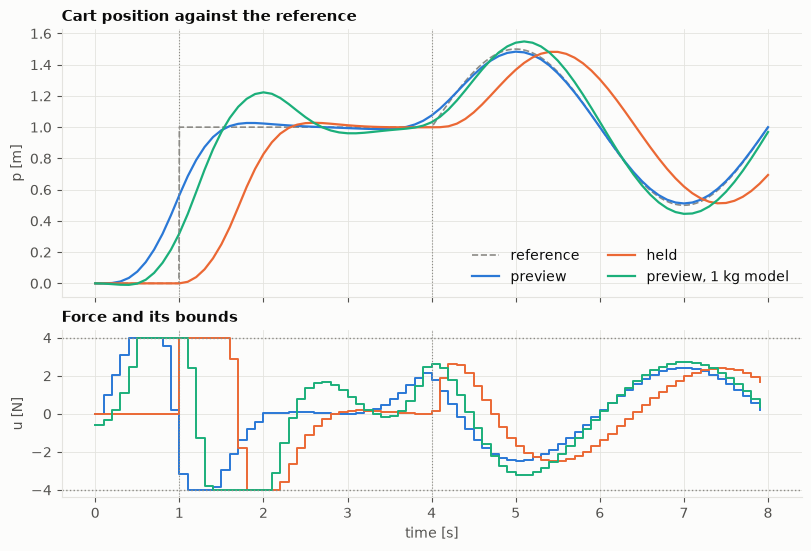

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.4), sharex=True, gridspec_kw={"height_ratios": [1.6, 1]})
fine = np.linspace(0.0, t[-1], 1601)
ax1.plot(fine, reference(fine)[:, 0], color=plotstyle.NEUTRAL, lw=1.2, ls="--", label="reference")
for (label, run), color in zip(runs.items(), (plotstyle.BLUE, plotstyle.ORANGE, plotstyle.AQUA), strict=True):
  ax1.plot(t, run.xs[:, 0], color=color, lw=1.6, label=label)
  ax2.step(t[:-1], run.us[:, 0], where="post", color=color, lw=1.4)
for ax in (ax1, ax2):
  for edge in (T_STEP, T_SINE):
    ax.axvline(edge, color=plotstyle.NEUTRAL, lw=0.8, ls=":")
ax1.set_ylabel("p [m]")
ax1.set_title("Cart position against the reference")
ax1.legend(loc="lower right", ncol=2)
for bound in (-U_MAX, U_MAX):
  ax2.axhline(bound, color=plotstyle.NEUTRAL, lw=1, ls=":")
ax2.set_ylabel("u [N]")
ax2.set_title("Force and its bounds")
ax2.set_xlabel("time [s]")
plt.show()

The preview controller starts moving at once: the step is inside its first horizon. It is at
0.565 m when the step happens and rides the sine almost on it, an RMS error of 0.095 m over the run
and 0.017 m over the sine. The held controller cannot know the step until it happens, so it sits
at 0 m until 1 s, and on the sine it trails, since its terminal equality asks it to reach the
reference of now two seconds later: 0.310 m and 0.212 m. Both saturate the force on the step,
none elsewhere. Told the cart is half as heavy as it is, the preview controller plans with twice
the acceleration it gets: it overshoots the step by 0.22 m and each swing of the sine, 0.135 m. PIQP takes a
median of 6 to 8 iterations and some 60 µs per solve.

## What the preview sees

The solver returns the whole plan. Half a second in, before the step, the preview controller's plan
already climbs to meet the step, while the held controller's plan stays at its reference, zero.

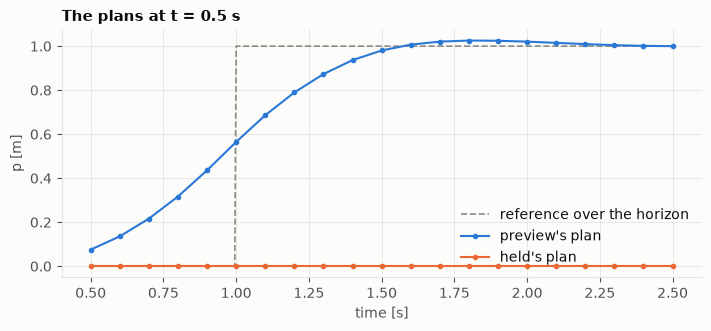

preview plan: OK, cost 9.597, x_N = [1.00000000e+00 3.37642644e-18]


In [7]:
k = 5
def plan(ctrl, x, r):
  xs, us, _, info = ctrl.solve(x, np.array([M_TRUE]), r, ocp.initial_guess(ctrl.problem, METHOD, x))  # a QP: any warm start gives this solution
  return SimpleNamespace(xs=xs, us=us, status=sc.Status(int(info.status)), cost=float(info.objective))


plan_preview = plan(preview, run_preview.xs[k], window(k))
plan_held = plan(held, run_held.xs[k], reference(DT * k))
horizon_t = DT * (k + np.arange(N + 1))
fig, ax = plt.subplots(figsize=(7, 3.2))
fine = np.linspace(horizon_t[0], horizon_t[-1], 401)
ax.plot(fine, reference(fine)[:, 0], color=plotstyle.NEUTRAL, lw=1.2, ls="--", label="reference over the horizon")
ax.plot(horizon_t, plan_preview.xs[:, 0], "o-", ms=3, color=plotstyle.BLUE, lw=1.5, label="preview's plan")
ax.plot(horizon_t, plan_held.xs[:, 0], "o-", ms=3, color=plotstyle.ORANGE, lw=1.5, label="held's plan")
ax.set_xlabel("time [s]")
ax.set_ylabel("p [m]")
ax.set_title(f"The plans at t = {DT * k:.1f} s")
ax.legend(loc="lower right")
plt.show()
print(f"preview plan: {plan_preview.status.name}, cost {plan_preview.cost:.3f}, x_N = {plan_preview.xs[-1]}")

The preview's plan ends at the reference's last value, $x_N = r_N = (1, 0)$, as its terminal
equality says, and trades a little error before the step for much less after it.

## One solve against NumPy

Without the force bounds the MPC is an equality-constrained QP, which NumPy solves directly.
Writing the states through the controls, $x_k = \Phi_k x_0 + \Gamma_k u$ with $\Phi_k = A^k$ and
$\Gamma_k$ the columns $A^{k-1-j} B / m$, the forces minimize
$\tfrac12 u^\top H u + g^\top u$ subject to $\Gamma_N u = r_N - \Phi_N x_0$, where

$$
H = 2\Big(R\, I + \sum_{k<N} \Gamma_k^\top Q\, \Gamma_k\Big), \qquad g = 2\sum_{k<N} \Gamma_k^\top Q\, (\Phi_k x_0 - r_k),
$$

and the optimality conditions are one linear system (the factor 2 cancels). The model comes from
`si.zoh`, so this also checks the step Function. The solve checked is the one at step 60, in the
sine, where the force bounds are inactive and the two problems have the same solution.

In [8]:
CHECK = 60


def kkt(x0, r, mass):
  a, b = si.zoh(A_CONTINUOUS, B_CONTINUOUS / mass, DT)
  refs = r.reshape(N + 1, 2)
  phi = np.stack([np.linalg.matrix_power(a, k) for k in range(N + 1)])
  gamma = np.zeros((N + 1, 2, N))
  for k in range(1, N + 1):
    for j in range(k):
      gamma[k, :, j] = (np.linalg.matrix_power(a, k - 1 - j) @ b)[:, 0]
  hessian, gradient = R[0, 0] * np.eye(N), np.zeros(N)
  for k in range(N):
    hessian += gamma[k].T @ Q @ gamma[k]
    gradient += gamma[k].T @ Q @ (phi[k] @ x0 - refs[k])
  lhs = np.block([[hessian, gamma[N].T], [gamma[N], np.zeros((2, 2))]])
  return np.linalg.solve(lhs, np.r_[-gradient, refs[N] - phi[N] @ x0])[:N]


check = plan(preview, run_preview.xs[CHECK], window(CHECK))
check_u_max = float(np.abs(check.us).max())
kkt_gap = float(np.abs(check.us.ravel() - kkt(run_preview.xs[CHECK], window(CHECK), M_TRUE)).max())
terminal_gap = float(np.abs(check.xs[-1] - window(CHECK)[-2:]).max())
print(f"solve at step {CHECK}: {check.status.name}, largest |u| {check_u_max:.3f} N (bound {U_MAX})")
print(f"forces within {kkt_gap:.1e} of NumPy's solve, x_N within {terminal_gap:.1e} of r_N")

solve at step 60: OK, largest |u| 2.396 N (bound 4.0)
forces within 6.8e-09 of NumPy's solve, x_N within 6.2e-13 of r_N


The largest planned force is 2.4 N, inside the 4 N bound, and PIQP's forces agree with the linear
solve to 7e-9, at PIQP's tolerance of 1e-10. The terminal equality holds to rounding.

## Checks

In [9]:
assert params == [("mass", ()), ("r", (2,))]
assert solver_inputs == {"x0": (2,), "mass": (1,), "r": (42,), "warm": (168,)}
assert held_solver_inputs["r"] == (2,)
assert step_gap < 1e-12
assert check.status.name == "OK" and check_u_max < 3.9
assert kkt_gap < 1e-7 and terminal_gap < 1e-8
assert statuses == ["OK"] and u_max <= 4 + 1e-6
assert p_at_step_preview > 0.3 and abs(p_at_step_held) < 1e-8  # the preview moves before the step
assert rms_preview < 0.5 * rms_held and rms_sine_preview < 0.2 * rms_sine_held
assert rms_nominal_mass > rms_preview
print("10 checks passed")

10 checks passed


## The generated C

The solver and the shift are Functions, so the whole controller is one,
`law(x0, mass, r, warm) -> (u, warm_next)`: PIQP nested in it and the warm start's shift in its
code. A C caller keeps one buffer of 168 doubles between calls and passes the mass and the 21
reference points at each.

In [10]:
@sc.function(
  sc.L("x0", 2), sc.L("mass", 1), sc.L("r", 2 * (N + 1)), sc.L("warm", METHOD.warm_size(preview.problem)), output=sc.G("u", "warm_next"), name="tracking_preview_law"
)
def law(x0, mass, r, warm):
  _, us, point, _ = preview.solve(x0, mass, r, warm)
  return us[0], preview.shift(point)


u, _ = law(x0, np.array([M_TRUE]), window(0), ocp.initial_guess(preview.problem, METHOD, x0))
assert np.abs(u - run_preview.us[0]).max() < 1e-12  # the law's first force is the closed loop's
module = write_module(law, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB; the typed buffers in {module.header_name}:")
print(
  "\n".join(line for line in module.header.splitlines() if line.startswith("typedef struct") and "double data[" in line and "workspace" not in line)
)

tracking_preview_law.c: 636 lines, 34 kB; the typed buffers in tracking_preview_law.h:
typedef struct { SCALY_ALIGNAS(16) double data[2]; } tracking_preview_law_x0_t;
typedef struct { SCALY_ALIGNAS(16) double data[1]; } tracking_preview_law_mass_t;
typedef struct { SCALY_ALIGNAS(16) double data[42]; } tracking_preview_law_r_t;
typedef struct { SCALY_ALIGNAS(16) double data[168]; } tracking_preview_law_warm_t;
typedef struct { SCALY_ALIGNAS(16) double data[1]; } tracking_preview_law_u_t;
typedef struct { SCALY_ALIGNAS(16) double data[168]; } tracking_preview_law_warm_next_t;
